<h1><b>Structural Health Monitoring Exploratory Data Analysis</b></h1>

<h4><b>Background Information</b></h4>

The SHM task in NEBULA X Problem Statement 3 estimates cumulative fatigue damage from dynamic-stress recordings. The supplied information kit describes reference targets derived from rainflow counting and Miner’s rule. All supplied recordings represent healthy operating conditions; the target is a continuous damage quantity, not a structural-fault label.

<h4><b>Objective</b></h4>

This notebook establishes data quality, examines damage variation, and explores file-level signal summaries that can inform later regression experiments. It does not train models, infer Test labels, or estimate remaining useful life.

<h4><b>Project Workflow</b></h4>

The analysis inspects files and labels, validates recordings, explores target distributions and representative traces, constructs descriptive features, examines associations and outliers, compares Train and Test, and prepares a recording-level validation plan.

<h4><b>Dataset Used</b></h4>

`PS3/02_Datasets/SHM` contains `Train`, `Test`, and `Train_Labels.csv`. The information kit specifies 64 labelled Train files and 16 unlabelled Test files. CSV recordings are loaded without a header to preserve the first sample. Sampling frequency, stress units, material S–N constants, and per-file line/load identifiers are not supplied in the available schema. File numbers are arbitrary identifiers, not acquisition order.

The task definition and metric come from `PS3/03_References/SHM/SHM_Info_Kit.md`.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup and Configuration</a>
    <ul>
      <li><a href="#1-1">1.1 Libraries and Display Settings</a></li>
      <li><a href="#1-2">1.2 Dataset Location and Environment</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Dataset Inventory and Label Integrity</a>
    <ul>
      <li><a href="#2-1">2.1 File Inventory and Raw Preview</a></li>
      <li><a href="#2-2">2.2 Label Coverage and Target Validity</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Recording Quality and Schema Validation</a>
    <ul>
      <li><a href="#3-1">3.1 Headerless Loading and Per-File Quality Audit</a></li>
      <li><a href="#3-2">3.2 Exact Duplicates and Unusual Flat Stretches</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Damage Target Distribution and Scoring Implications</a>
    <ul>
      <li><a href="#4-1">4.1 Target Range and Distribution</a></li>
      <li><a href="#4-2">4.2 Sensitivity of Relative Error</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Representative Traces and Within-File Variation</a>
    <ul>
      <li><a href="#5-1">5.1 Representative Signal Traces</a></li>
      <li><a href="#5-2">5.2 Block-Level Stationarity Screen</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: File-Level Feature Exploration</a>
    <ul>
      <li><a href="#6-1">6.1 Amplitude and Cycle-Related Feature Definitions</a></li>
      <li><a href="#6-2">6.2 Spectral and Serial-Dependence Feature Definitions</a></li>
      <li><a href="#6-3">6.3 Feature Assembly and Integrity</a></li>
      <li><a href="#6-4">6.4 Representative Spectra and Lag Correlations</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Feature Distributions and Outlier Review</a>
    <ul>
      <li><a href="#7-1">7.1 File-Level Distributions</a></li>
      <li><a href="#7-2">7.2 Robust Train-Reference Outlier Screen</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Feature Associations and Redundancy</a>
    <ul>
      <li><a href="#8-1">8.1 Target Associations</a></li>
      <li><a href="#8-2">8.2 Redundant Feature Groups</a></li>
      <li><a href="#8-3">8.3 Association Uncertainty and Influence</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Train and Test Coverage Comparison</a>
    <ul>
      <li><a href="#9-1">9.1 Train-Scaled Distribution Shift</a></li>
      <li><a href="#9-2">9.2 Feature-Space Coverage</a></li>
    </ul>
  </li>
  <li><a href="#section-10">Section 10: Validation Planning and Leakage Controls</a>
    <ul>
      <li><a href="#10-1">10.1 Candidate Recording-Level Folds</a></li>
      <li><a href="#10-2">10.2 Modelling Constraints and Evaluation Plan</a></li>
    </ul>
  </li>
  <li><a href="#section-11">Section 11: Reproducibility and Results Inventory</a>
    <ul>
      <li><a href="#11-1">11.1 Analysis Summary</a></li>
    </ul>
  </li>
  <li><a href="#section-12">Section 12: Findings, Limitations, and Modelling Handoff</a>
    <ul>
      <li><a href="#12-1">12.1 Verified Data and Target Findings</a></li>
      <li><a href="#12-2">12.2 Feature and Validation Implications</a></li>
      <li><a href="#12-3">12.3 Unresolved Information and Scope</a></li>
    </ul>
  </li>
</ul>

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup and Configuration</b></h2>
</div>

This section loads the numerical and plotting libraries, locates the SHM dataset, and records the execution environment for reproducibility.

<blockquote><h3 id="1-1"><b>1.1 Libraries and Display Settings</b></h3></blockquote>

The following cell imports the dependencies and defines consistent plot settings and a fixed random seed.

In [1]:
from pathlib import Path
import os
import hashlib
import platform
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats
from IPython.display import display

SEED = 2026
COLORS = {'Train':'#16857b', 'Test':'#8256b3'}
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False,
                    'axes.spines.right':False, 'figure.constrained_layout.use':True})
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 90)

<blockquote><h3 id="1-2"><b>1.2 Dataset Location and Environment</b></h3></blockquote>

The dataset is discovered from the repository or PS3 directory. `TFD_PS3_DIR` can point to a different PS3 directory. Package versions identify the environment used for the saved results.

In [2]:
def find_shm_dir():
    """Locate SHM below an explicit PS3 directory or a repository ancestor."""
    if os.environ.get('TFD_PS3_DIR'):
        candidates = [Path(os.environ['TFD_PS3_DIR']).expanduser() / '02_Datasets/SHM']
    else:
        candidates = [p / suffix for p in [Path.cwd(), *Path.cwd().parents]
                      for suffix in ['PS3/02_Datasets/SHM', '02_Datasets/SHM']]
    for candidate in candidates:
        if (candidate / 'Train_Labels.csv').is_file():
            return candidate.resolve()
    raise FileNotFoundError('Set TFD_PS3_DIR to the PS3 directory or run inside the repository.')

SHM_DIR = find_shm_dir()
display(pd.Series({'Python':platform.python_version(), **{
    name:importlib.metadata.version(name) for name in ['numpy','pandas','scipy','matplotlib']}}))
print('Dataset:', SHM_DIR)

Python        3.13.7
numpy          2.5.3
pandas         3.0.5
scipy         1.18.1
matplotlib    3.11.2
dtype: str

Dataset: C:\Users\user\OneDrive - Singapore Polytechnic\NebulaX-Hackathon-ProblemStatement\PS3\02_Datasets\SHM


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Dataset Inventory and Label Integrity</b></h2>
</div>

This section confirms available files, previews the raw format, and validates the one-label-per-recording relationship before signal processing.

<blockquote><h3 id="2-1"><b>2.1 File Inventory and Raw Preview</b></h3></blockquote>

File sizes and counts provide an initial completeness check. Raw lines confirm whether the first line contains a measurement rather than a column header.

In [3]:
paths = {split:sorted((SHM_DIR / split).glob('*.csv')) for split in ['Train','Test']}
assert all(paths.values()), 'Both recording directories must contain CSV files.'
inventory = pd.DataFrame([{'dataset':split,'filename':p.name,'bytes':p.stat().st_size}
                          for split, files in paths.items() for p in files])
display(inventory.groupby('dataset').agg(files=('filename','size'), total_MB=('bytes',lambda s:s.sum()/1e6),
                                        min_bytes=('bytes','min'),max_bytes=('bytes','max')))
with paths['Train'][0].open() as handle:
    print('First five raw lines:', [next(handle).strip() for _ in range(5)])
labels = pd.read_csv(SHM_DIR / 'Train_Labels.csv')
display(labels.head())
display(labels.dtypes.astype(str).rename('dtype'))

,files,total_MB,min_bytes,max_bytes
dataset,,,,
Test,16,105.105801,6258288,6821085
Train,64,420.583612,6228033,6854270


First five raw lines: ['-0.17716719', '-1.1784055', '-0.17716719', '-0.95301855', '-1.3951238']


,filename,damage
0,train01.csv,0.103663
1,train02.csv,0.149209
2,train03.csv,0.111298
3,train04.csv,0.894736
4,train05.csv,0.054740


filename        str
damage      float64
Name: dtype, dtype: str

<blockquote><h3 id="2-2"><b>2.2 Label Coverage and Target Validity</b></h3></blockquote>

Exact filename matching prevents accidental alignment by row order. Missing, duplicated, non-numeric, non-finite, and non-positive targets are checked because the official metric divides by the true damage value.

In [4]:
assert set(labels.columns) == {'filename','damage'}, 'Unexpected label schema.'
labels['damage'] = pd.to_numeric(labels.damage, errors='raise')
train_names = {p.name for p in paths['Train']}
label_audit = pd.Series({
    'train_files':len(train_names), 'label_rows':len(labels),
    'duplicate_filenames':labels.filename.duplicated().sum(),
    'missing_label_cells':labels.isna().sum().sum(),
    'nonfinite_targets':(~np.isfinite(labels.damage)).sum(),
    'nonpositive_targets':labels.damage.le(0).sum(),
    'files_without_labels':len(train_names-set(labels.filename)),
    'labels_without_files':len(set(labels.filename)-train_names)})
display(label_audit)
assert label_audit.iloc[2:].eq(0).all(), 'Resolve label problems before target analysis.'
labels = labels.set_index('filename').sort_index()

train_files             64
label_rows              64
duplicate_filenames      0
missing_label_cells      0
nonfinite_targets        0
nonpositive_targets      0
files_without_labels     0
labels_without_files     0
dtype: int64

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Recording Quality and Schema Validation</b></h2>
</div>

This section scans every recording without dropping samples. It checks dimensions, numeric validity, repeated readings, flat stretches, and exact duplicate files before deeper analysis.

<blockquote><h3 id="3-1"><b>3.1 Headerless Loading and Per-File Quality Audit</b></h3></blockquote>

Each CSV is read with `header=None` and blank-line skipping disabled. Invalid readings are counted explicitly. Consecutive identical samples and long flat stretches are inspection signals; repeated quantised readings are not automatically duplicate records.

In [5]:
def longest_equal_run(x):
    """Return the longest run of exactly equal consecutive samples."""
    boundaries = np.r_[0, np.flatnonzero(x[1:] != x[:-1])+1, len(x)]
    return int(np.diff(boundaries).max()) if len(x) else 0

signals = {}
quality_rows = []
for split, files in paths.items():
    for p in files:
        raw = pd.read_csv(p, header=None, skip_blank_lines=False)
        numeric = raw.apply(pd.to_numeric, errors='coerce')
        values = numeric.to_numpy(dtype=float)
        x = values[:,0]
        finite = np.isfinite(values)
        quality_rows.append({'dataset':split, 'filename':p.name, 'rows':len(raw), 'columns':raw.shape[1],
            'source_dtype':str(raw.dtypes.iloc[0]), 'missing_cells':int(raw.isna().sum().sum()),
            'nonnumeric_cells':int((numeric.isna() & raw.notna()).sum().sum()),
            'infinite_cells':int(np.isinf(values).sum()), 'finite_fraction':finite.mean(),
            'unique_values':pd.Series(x).nunique(), 'constant_signal':pd.Series(x).nunique()<=1,
            'zero_fraction':np.mean(x==0), 'equal_step_fraction':np.mean(np.diff(x)==0),
            'longest_equal_run':longest_equal_run(x),
            'signal_hash':hashlib.sha256(values.astype('<f8').tobytes()).hexdigest()})
        signals[(split,p.name)] = x
quality = pd.DataFrame(quality_rows)
display(quality.drop(columns='signal_hash').groupby('dataset').agg({
    'rows':['min','max'], 'columns':['min','max'], 'missing_cells':'sum',
    'nonnumeric_cells':'sum','infinite_cells':'sum','constant_signal':'sum',
    'unique_values':['min','max'],'longest_equal_run':['median','max']}))
assert quality['columns'].eq(1).all(), 'Review unexpected multi-channel files.'
assert quality.finite_fraction.eq(1).all(), 'Resolve invalid values without silently dropping samples.'
assert quality.rows.gt(4096).all(), 'Review short recordings before spectral analysis.'

rows         columns     missing_cells nonnumeric_cells  \
            min     max     min max           sum              sum   
dataset                                                              
Test     581120  581120       1   1             0                0   
Train    581120  581120       1   1             0                0   

        infinite_cells constant_signal unique_values        longest_equal_run  \
                   sum             sum           min    max            median   
dataset                                                                         
Test                 0               0          2946  15743               7.0   
Train                0               0          1854  16628               7.0   

             
        max  
dataset      
Test      9  
Train     9

<blockquote><h3 id="3-2"><b>3.2 Exact Duplicates and Unusual Flat Stretches</b></h3></blockquote>

Numeric signal hashes identify identical recordings even when their filenames differ. The longest flat stretches are displayed for manual inspection. No samples are deduplicated or clipped.

,result
0,No exact duplicate recordings.


,dataset,filename,rows,unique_values,equal_step_fraction,longest_equal_run
0,Train,train01.csv,581120,6121,0.051580,9
27,Train,train28.csv,581120,6847,0.092055,9
47,Train,train48.csv,581120,6382,0.094416,9
49,Train,train50.csv,581120,6736,0.117071,9
70,Test,test07.csv,581120,6064,0.088472,9
6,Train,train07.csv,581120,5758,0.090111,8
13,Train,train14.csv,581120,3608,0.076129,8
20,Train,train21.csv,581120,3337,0.088089,8
28,Train,train29.csv,581120,3309,0.094982,8
30,Train,train31.csv,581120,15945,0.066702,8


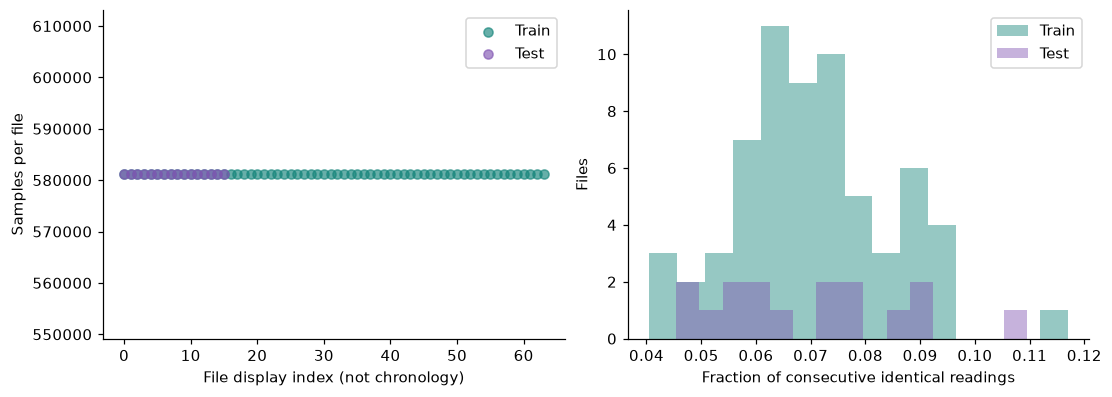

In [6]:
duplicate_files = quality.loc[quality.duplicated('signal_hash',keep=False), ['dataset','filename','signal_hash']]
display(duplicate_files if len(duplicate_files) else pd.DataFrame({'result':['No exact duplicate recordings.']}))
display(quality.nlargest(10,'longest_equal_run')[['dataset','filename','rows','unique_values',
                                               'equal_step_fraction','longest_equal_run']])
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
for split in ['Train','Test']:
    q = quality.query('dataset == @split')
    axes[0].scatter(np.arange(len(q)),q.rows,label=split,alpha=.65,color=COLORS[split])
    axes[1].hist(q.equal_step_fraction,bins=15,alpha=.45,label=split,color=COLORS[split])
axes[0].set(xlabel='File display index (not chronology)',ylabel='Samples per file')
axes[1].set(xlabel='Fraction of consecutive identical readings',ylabel='Files')
axes[0].legend(); axes[1].legend(); plt.show()

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Damage Target Distribution and Scoring Implications</b></h2>
</div>

This section examines target scale and imbalance across damage ranges. The official score is `max(0, 1 - MAPE)`, where MAPE is a fraction averaged across files.

<blockquote><h3 id="4-1"><b>4.1 Target Range and Distribution</b></h3></blockquote>

Raw and logarithmic damage distributions reveal skew and the coverage of small targets. A logarithmic view is valid only after positivity has been confirmed.

,damage
count,64.000000
mean,0.230147
std,0.263480
min,0.028620
5%,0.028828
10%,0.032546
25%,0.045889
50%,0.098931
75%,0.387633
90%,0.691946


Largest/smallest target ratio: 32.4363952941354


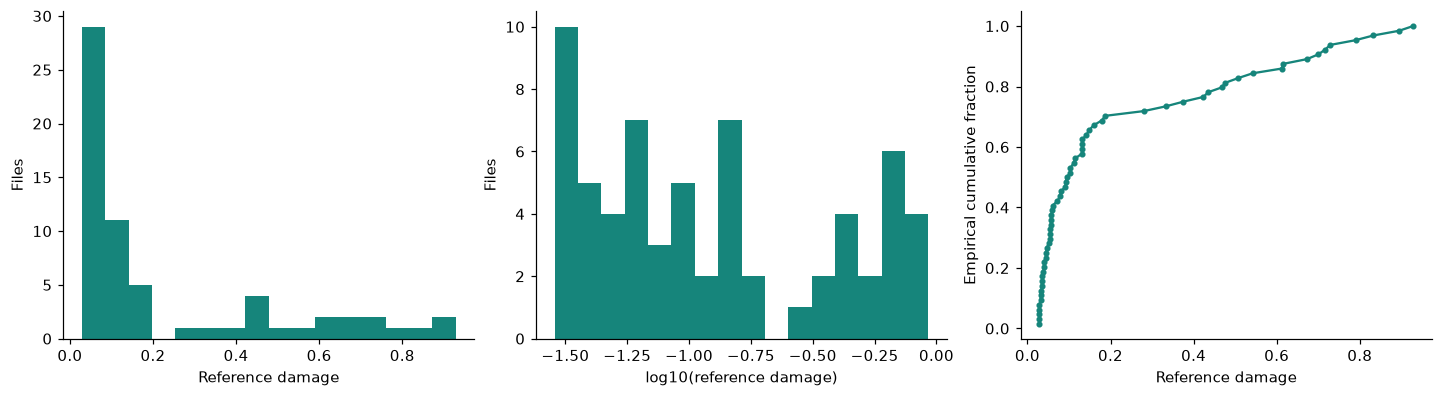

In [7]:
display(labels.damage.describe(percentiles=[.05,.1,.25,.5,.75,.9,.95]).to_frame())
print('Largest/smallest target ratio:', labels.damage.max()/labels.damage.min())
fig, axes = plt.subplots(1,3,figsize=(13,3.5))
axes[0].hist(labels.damage,bins=16,color=COLORS['Train'])
axes[0].set(xlabel='Reference damage',ylabel='Files')
axes[1].hist(np.log10(labels.damage),bins=16,color=COLORS['Train'])
axes[1].set(xlabel='log10(reference damage)',ylabel='Files')
axes[2].plot(np.sort(labels.damage),np.arange(1,len(labels)+1)/len(labels),marker='.',color=COLORS['Train'])
axes[2].set(xlabel='Reference damage',ylabel='Empirical cumulative fraction')
plt.show()

<blockquote><h3 id="4-2"><b>4.2 Sensitivity of Relative Error</b></h3></blockquote>

An illustrative fixed absolute error is evaluated at target quantiles to show how small targets receive greater relative penalties. This is a metric illustration, not a prediction or model score.

In [8]:
metric_example = labels.damage.quantile([0,.25,.5,.75,1]).rename('true_damage').to_frame()
metric_example['illustrative_absolute_error'] = .01
metric_example['relative_error_pct'] = 100*.01/metric_example.true_damage
display(metric_example)
target_bins = pd.qcut(labels.damage,4,labels=['Q1 low','Q2','Q3','Q4 high'])
display(labels.assign(target_band=target_bins).groupby('target_band',observed=True).damage.agg(['size','min','median','max']))

,true_damage,illustrative_absolute_error,relative_error_pct
0.00,0.028620,0.01,34.940249
0.25,0.045889,0.01,21.791499
0.50,0.098931,0.01,10.108081
0.75,0.387633,0.01,2.579757
1.00,0.928339,0.01,1.077193


,size,min,median,max
target_band,,,,
Q1 low,16,0.028620,0.033801,0.045191
Q2,16,0.046122,0.058627,0.094677
Q3,16,0.103185,0.137201,0.375658
Q4 high,16,0.423559,0.644457,0.928339


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Representative Traces and Within-File Variation</b></h2>
</div>

This section examines recordings across Train damage levels and measures local variation. Sample index is used because duration and sampling rate are not specified numerically.

<blockquote><h3 id="5-1"><b>5.1 Representative Signal Traces</b></h3></blockquote>

Files nearest four target quantiles provide a reproducible range of examples. Full-record displays use min–max envelopes to preserve extremes during visual compression; a short raw excerpt retains individual samples.

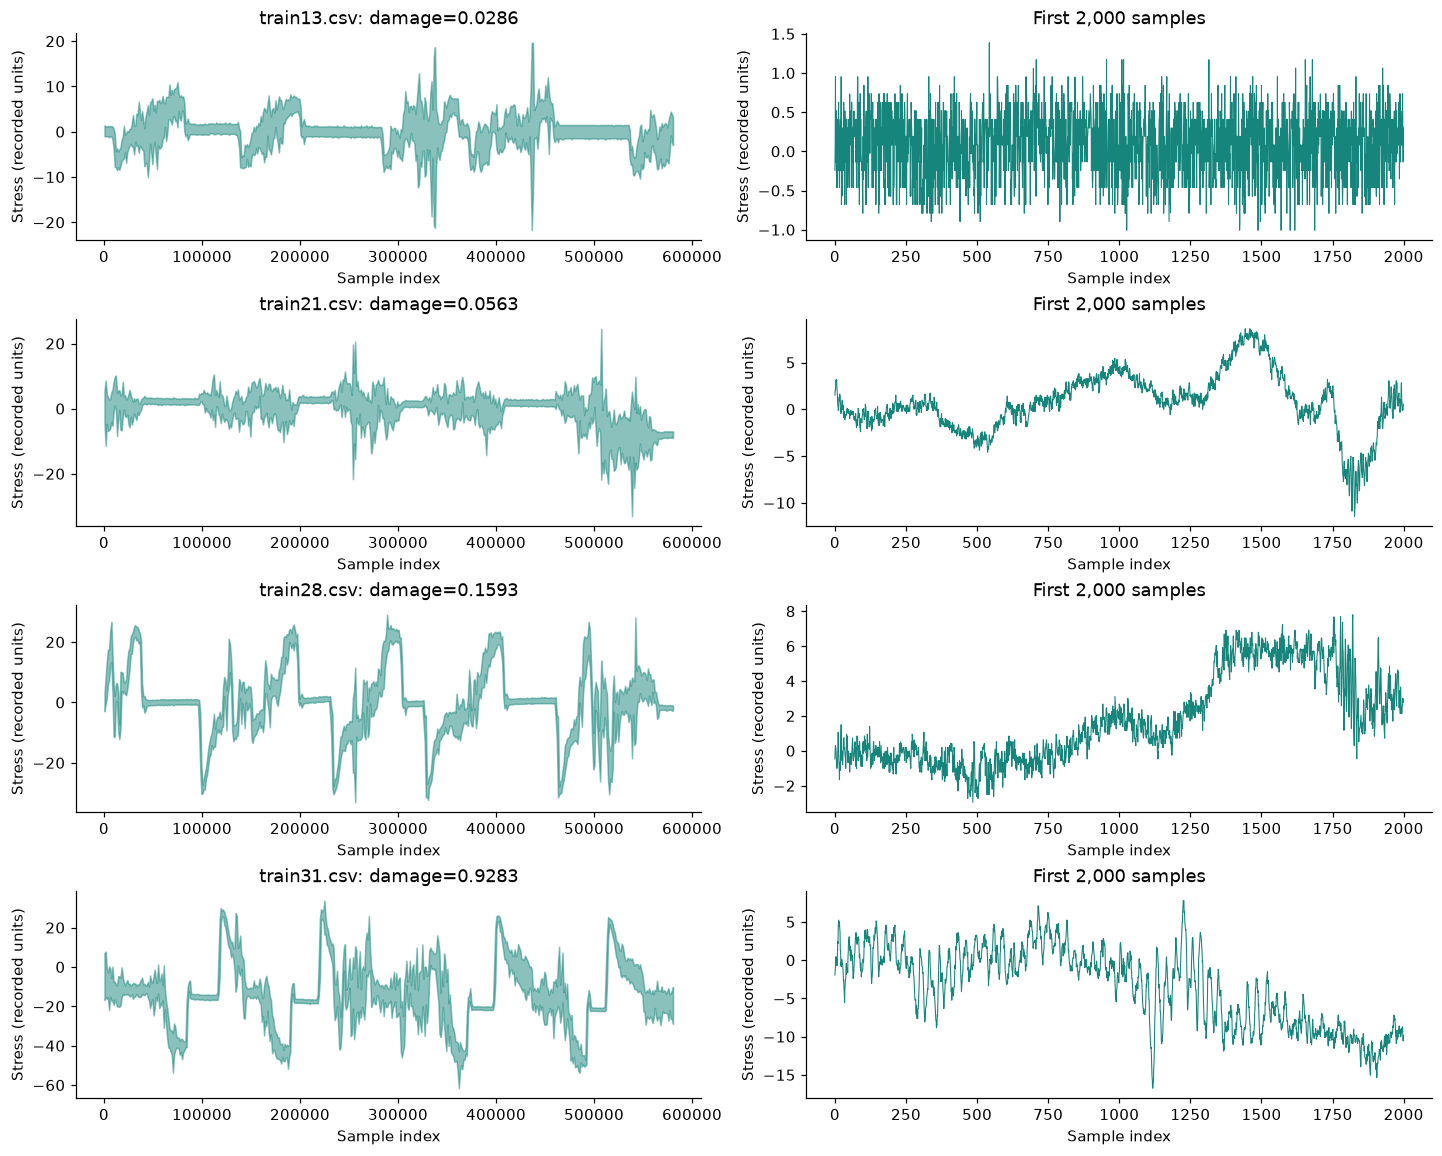

In [9]:
example_names = list(dict.fromkeys((labels.damage-v).abs().idxmin() for v in labels.damage.quantile([0,.33,.67,1])))
fig, axes = plt.subplots(len(example_names),2,figsize=(13,2.6*len(example_names)),squeeze=False)
for row,name in enumerate(example_names):
    x = signals[('Train',name)]
    blocks = np.array_split(np.arange(len(x)),500)
    centers = [b.mean() for b in blocks]
    axes[row,0].fill_between(centers,[x[b].min() for b in blocks],[x[b].max() for b in blocks],alpha=.5,color=COLORS['Train'])
    axes[row,0].set(title=f'{name}: damage={labels.loc[name,"damage"]:.4f}',xlabel='Sample index',ylabel='Stress (recorded units)')
    axes[row,1].plot(np.arange(min(2000,len(x))),x[:2000],lw=.7,color=COLORS['Train'])
    axes[row,1].set(title='First 2,000 samples',xlabel='Sample index',ylabel='Stress (recorded units)')
plt.show()

<blockquote><h3 id="5-2"><b>5.2 Block-Level Stationarity Screen</b></h3></blockquote>

Ten sequential blocks per recording summarise changes in mean, standard deviation, and range. Blocks are descriptive views of the same labelled file and must not be treated as independently labelled training examples.

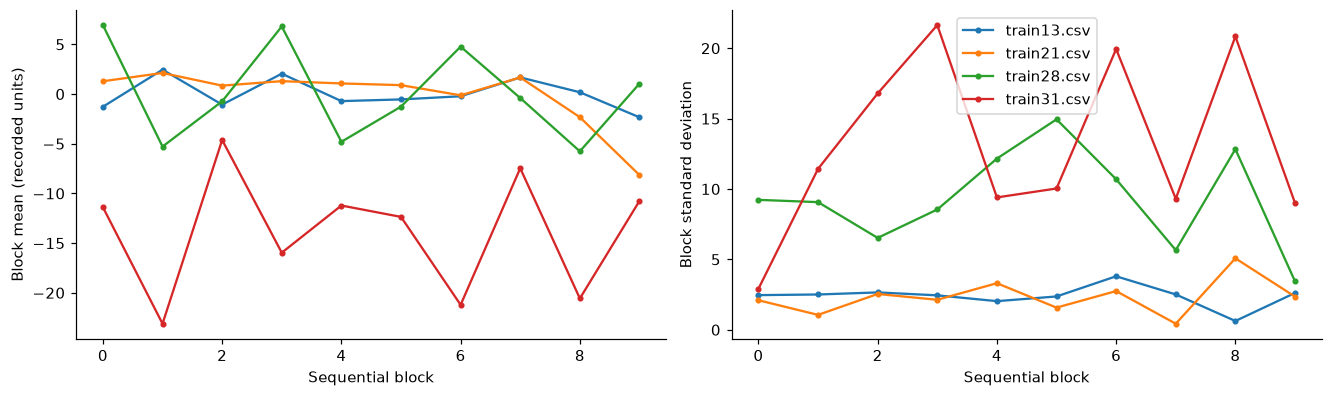

In [10]:
block_rows=[]
for (split,name),x in signals.items():
    for j,b in enumerate(np.array_split(x,10)):
        block_rows.append({'dataset':split,'filename':name,'block':j,'mean':b.mean(),
                           'std':b.std(),'range':np.ptp(b),'rms':np.sqrt(np.mean(b*b))})
blocks = pd.DataFrame(block_rows)
fig, axes = plt.subplots(1,2,figsize=(12,3.5))
for name in example_names:
    b=blocks.query("dataset == 'Train' and filename == @name")
    axes[0].plot(b.block,b['mean'],marker='.',label=name)
    axes[1].plot(b.block,b['std'],marker='.',label=name)
axes[0].set(xlabel='Sequential block',ylabel='Block mean (recorded units)')
axes[1].set(xlabel='Sequential block',ylabel='Block standard deviation')
axes[1].legend(); plt.show()

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: File-Level Feature Exploration</b></h2>
</div>

This section constructs transparent amplitude, variation, reversal, and spectral summaries. Features remain descriptive candidates; no feature selection, scaling, or regression is fitted.

<blockquote><h3 id="6-1"><b>6.1 Amplitude and Cycle-Related Feature Definitions</b></h3></blockquote>

Each recording is reduced to distribution and sample-to-sample summaries. Adjacent turning-point ranges are unpaired excursion proxies, not rainflow cycle counts or Miner damage. Cubic and fifth-power amplitude summaries explore sensitivity to large excursions; their exponents are not known material constants.

In [11]:
def time_features(x):
    """Describe a finite one-dimensional signal without altering its stored samples."""
    centered = x-x.mean()
    std = x.std()
    delta = np.diff(x)
    # Remove plateaus only in the temporary turning-point representation.
    compressed = x[np.r_[True,delta!=0]]
    d = np.diff(compressed)
    turns = compressed[np.r_[True,d[:-1]*d[1:]<0,True]] if len(compressed)>1 else compressed
    ranges = np.abs(np.diff(turns))
    return dict(mean=x.mean(), std=std, rms=np.sqrt(np.mean(x*x)), minimum=x.min(),maximum=x.max(),
        peak_to_peak=np.ptp(x), iqr=np.quantile(x,.75)-np.quantile(x,.25),
        abs_centered_p95=np.quantile(abs(centered),.95),abs_centered_p99=np.quantile(abs(centered),.99),
        skew=stats.skew(x) if std else np.nan, excess_kurtosis=stats.kurtosis(x) if std else np.nan,
        crest_factor=np.max(abs(centered))/std if std else np.nan,
        centered_abs_moment3=np.mean(abs(centered)**3),centered_abs_moment5=np.mean(abs(centered)**5),
        diff_rms=np.sqrt(np.mean(delta**2)), total_variation_per_step=np.mean(abs(delta)),
        mean_crossing_fraction=np.mean(np.signbit(centered[1:])!=np.signbit(centered[:-1])),
        reversal_density=max(len(turns)-2,0)/len(x),
        excursion_p95=np.quantile(ranges,.95) if len(ranges) else 0,
        excursion_cube_sum=np.sum((ranges/2)**3))

<blockquote><h3 id="6-2"><b>6.2 Spectral and Serial-Dependence Feature Definitions</b></h3></blockquote>

Welch spectra use `fs=1`, so frequency is cycles per sample, not hertz. Fixed exploratory bands describe relative spectral shape. Demeaned lag correlations measure serial dependence without inferring acquisition time or physical resonance frequencies.

In [12]:
def spectral_features(x):
    """Return normalised-frequency summaries and within-file lag correlations."""
    centered=x-x.mean()
    f,p=signal.welch(centered,fs=1.0,nperseg=4096,noverlap=2048,detrend='constant')
    mass=p/p.sum() if p.sum()>0 else np.full_like(p,np.nan)
    nonzero=mass>0
    features={'spectral_centroid':np.sum(f*mass),
              'dominant_frequency':f[1:][np.argmax(p[1:])],
              'spectral_entropy':-np.sum(mass[nonzero]*np.log(mass[nonzero]))/np.log(len(mass))}
    for low,high,name in [(0,.01,'low'),(.01,.1,'mid'),(.1,.50001,'high')]:
        features['spectral_fraction_'+name]=mass[(f>=low)&(f<high)].sum()
    for lag in [1,10,100,1000]:
        features[f'autocorr_lag_{lag}']=np.corrcoef(centered[:-lag],centered[lag:])[0,1] if centered.std()>0 else np.nan
    return features,(f,p)

<blockquote><h3 id="6-3"><b>6.3 Feature Assembly and Integrity</b></h3></blockquote>

One feature row is created per recording, with Train labels joined by filename. Block-variation summaries augment global features. Undefined or constant features are identified before later modelling.

In [13]:
feature_rows=[]; spectra={}
for (split,name),x in signals.items():
    spectral,psd=spectral_features(x)
    spectra[(split,name)]=psd
    b=blocks.query('dataset == @split and filename == @name')
    feature_rows.append({'dataset':split,'filename':name,**time_features(x),**spectral,
        'block_std_cv':b['std'].std()/b['std'].mean() if b['std'].mean()>0 else np.nan,
        'block_mean_range':np.ptp(b['mean']), 'block_std_max_min_ratio':b['std'].max()/b['std'].min() if b['std'].min()>0 else np.nan})
features=pd.DataFrame(feature_rows).set_index(['dataset','filename'])
train_features=features.loc['Train'].join(labels,validate='one_to_one')
test_features=features.loc['Test']
FEATURES=list(features.columns)
feature_quality=pd.DataFrame({'train_missing':train_features[FEATURES].isna().sum(),
    'test_missing':test_features.isna().sum(),
    'train_nonfinite':(~np.isfinite(train_features[FEATURES])).sum(),
    'train_unique':train_features[FEATURES].nunique()})
display(feature_quality)
display(train_features.head())
assert train_features.damage.notna().all()
usable=[c for c in FEATURES if feature_quality.loc[c,'train_nonfinite']==0 and feature_quality.loc[c,'train_unique']>1]

,train_missing,test_missing,train_nonfinite,train_unique
mean,0,0,0,64
std,0,0,0,64
rms,0,0,0,64
minimum,0,0,0,64
maximum,0,0,0,64
peak_to_peak,0,0,0,64
iqr,0,0,0,64
abs_centered_p95,0,0,0,64
abs_centered_p99,0,0,0,64
skew,0,0,0,64


,mean,std,rms,minimum,maximum,peak_to_peak,iqr,abs_centered_p95,abs_centered_p99,skew,excess_kurtosis,crest_factor,centered_abs_moment3,centered_abs_moment5,diff_rms,...,excursion_cube_sum,spectral_centroid,dominant_frequency,spectral_entropy,spectral_fraction_low,spectral_fraction_mid,spectral_fraction_high,autocorr_lag_1,autocorr_lag_10,autocorr_lag_100,autocorr_lag_1000,block_std_cv,block_mean_range,block_std_max_min_ratio,damage
filename,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
train01.csv,5.935077,8.631420,10.475044,-19.343730,39.391250,58.734980,10.996284,17.761441,21.624938,-0.304332,0.014210,3.876091,1041.355260,2.946708e+05,0.841824,...,205441.848170,0.012095,0.000244,0.397479,0.915199,0.054173,0.030628,0.995244,0.988704,0.957527,0.866089,0.445383,11.071185,4.713801,0.103663
train02.csv,-7.732028,10.753981,13.245089,-37.650806,25.297182,62.947988,7.470424,22.439849,28.883700,0.179383,0.743291,3.071347,2287.322852,1.166672e+06,0.524750,...,163429.900275,0.007092,0.000244,0.302764,0.915754,0.068899,0.015346,0.998809,0.992963,0.987326,0.924217,0.469235,10.589798,7.110304,0.149209
train03.csv,1.926783,9.019781,9.223283,-28.079456,29.944937,58.024393,8.550382,19.263687,24.823290,-0.191601,0.661141,3.326715,1321.671841,4.792994e+05,0.669239,...,219183.936186,0.009664,0.000244,0.342365,0.919101,0.058115,0.022784,0.997247,0.990681,0.977926,0.888239,0.341659,10.502928,3.381594,0.111298
train04.csv,-2.477905,6.969852,7.397219,-54.097850,38.489470,92.587320,8.333540,14.304304,17.560720,0.112379,0.206409,7.406176,562.468668,1.145216e+05,0.835037,...,929051.261867,0.010491,0.000244,0.470885,0.855030,0.127466,0.017504,0.992823,0.943288,0.840245,0.662195,0.236010,7.461969,2.022757,0.894736
train05.csv,3.074598,8.830383,9.350337,-19.364319,29.429405,48.793724,8.235748,18.548492,21.584282,0.076483,0.260781,2.984560,1184.450097,3.516440e+05,0.476161,...,62277.741741,0.006447,0.000244,0.295771,0.951491,0.032378,0.016131,0.998546,0.995645,0.987082,0.913296,0.374493,9.412066,3.311485,0.054740


<blockquote><h3 id="6-4"><b>6.4 Representative Spectra and Lag Correlations</b></h3></blockquote>

Example spectra compare signal energy across normalised frequencies. Lag-correlation summaries assess dependence within recordings and explain why individual sample rows cannot be randomly split for file-level regression.

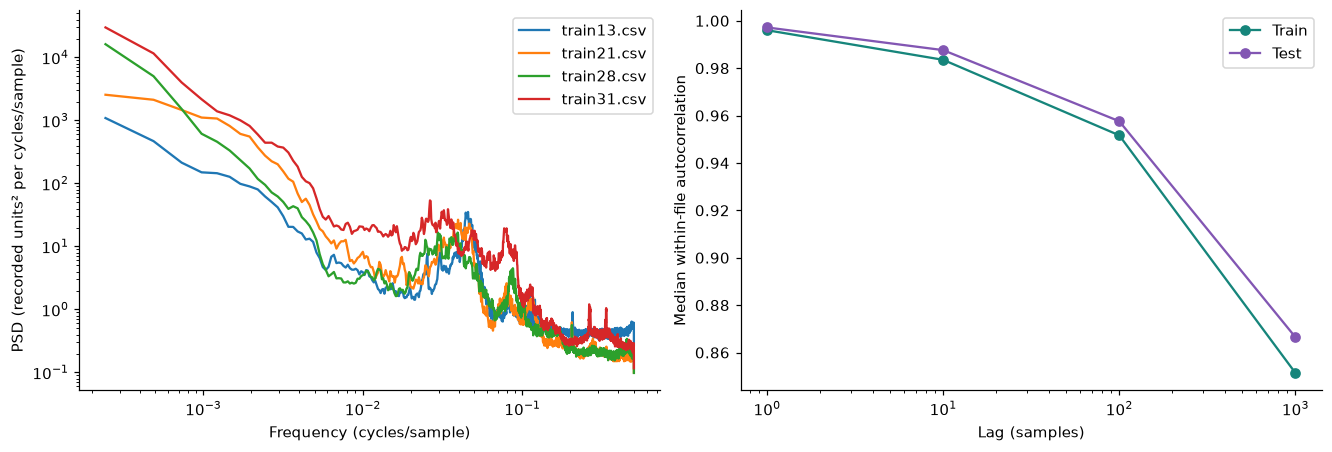

In [14]:
fig, axes=plt.subplots(1,2,figsize=(12,4))
for name in example_names:
    f,p=spectra[('Train',name)]
    axes[0].loglog(f[1:],p[1:],label=name)
axes[0].set(xlabel='Frequency (cycles/sample)',ylabel='PSD (recorded units² per cycles/sample)')
axes[0].legend()
lags=[1,10,100,1000]
for split,frame in [('Train',train_features),('Test',test_features)]:
    axes[1].plot(lags,[frame[f'autocorr_lag_{k}'].median() for k in lags],marker='o',label=split,color=COLORS[split])
axes[1].set(xscale='log',xlabel='Lag (samples)',ylabel='Median within-file autocorrelation')
axes[1].legend(); plt.show()

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Feature Distributions and Outlier Review</b></h2>
</div>

This section examines file-level feature spread and robust outliers. Every recording is described as healthy in the information kit; large values do not establish structural faults.

<blockquote><h3 id="7-1"><b>7.1 File-Level Distributions</b></h3></blockquote>

Histograms provide one observation per file and compare candidate feature scales. Long signals therefore do not receive greater weight merely because they contain more rows.

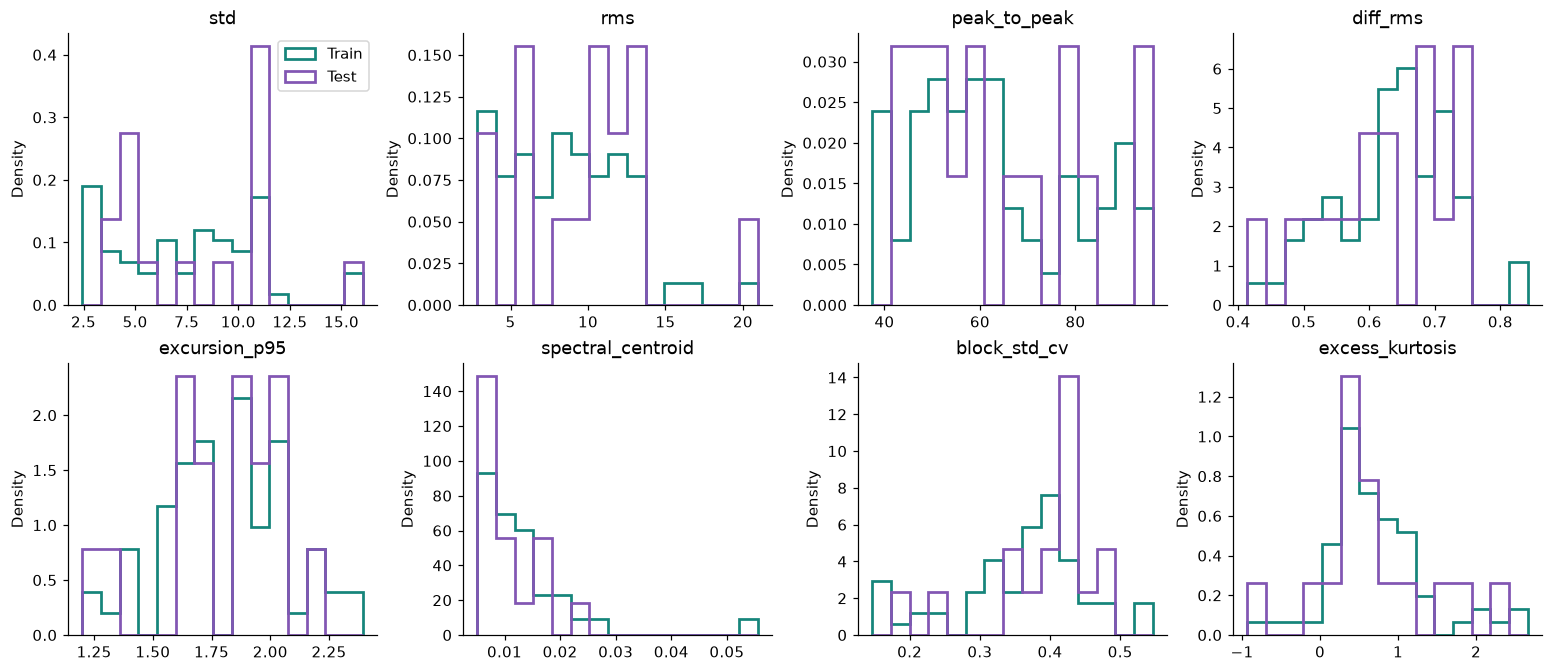

In [15]:
CORE=['std','rms','peak_to_peak','diff_rms','excursion_p95','spectral_centroid','block_std_cv','excess_kurtosis']
fig,axes=plt.subplots(2,4,figsize=(14,6))
for ax,col in zip(axes.flat,CORE):
    edges=np.histogram_bin_edges(features[col].dropna(),bins=15)
    for split,frame in [('Train',train_features),('Test',test_features)]:
        ax.hist(frame[col].dropna(),bins=edges,density=True,histtype='step',lw=1.8,label=split,color=COLORS[split])
    ax.set(title=col,ylabel='Density')
axes.flat[0].legend(); plt.show()

<blockquote><h3 id="7-2"><b>7.2 Robust Train-Reference Outlier Screen</b></h3></blockquote>

Train medians and MAD values define exploratory robust scores. Absolute scores above 3.5 identify review cases, with zero-MAD features excluded. Flags are retained alongside the original recordings and targets; no threshold is tuned using Test.

In [16]:
reference=train_features[CORE].median()
mad=(train_features[CORE]-reference).abs().median()
display(pd.DataFrame({'train_median':reference,'train_MAD':mad,'excluded_zero_MAD':mad.eq(0)}))
robust=.67448975*(features[CORE]-reference)/mad.replace(0,np.nan)
outlier_review=features[[]].copy()
outlier_review['flag_count']=robust.abs().gt(3.5).sum(axis=1)
outlier_review['max_abs_robust_z']=robust.abs().max(axis=1)
outlier_review['flagged_features']=robust.abs().gt(3.5).apply(lambda r:', '.join(r.index[r]),axis=1)
display(outlier_review.groupby(level='dataset').flag_count.agg(files='size',flagged_files=lambda s:s.gt(0).sum()))
display(outlier_review.sort_values('max_abs_robust_z',ascending=False).head(12))

,train_median,train_MAD,excluded_zero_MAD
std,7.958802,2.853446,False
rms,8.552657,2.979526,False
peak_to_peak,59.034465,10.510730,False
diff_rms,0.644320,0.056017,False
excursion_p95,1.845284,0.212591,False
spectral_centroid,0.011131,0.004309,False
block_std_cv,0.376229,0.048180,False
excess_kurtosis,0.649187,0.312459,False


,files,flagged_files
dataset,,
Test,16,0
Train,64,4


flag_count  max_abs_robust_z   flagged_features
dataset filename                                                    
Train   train13.csv           1          6.954298  spectral_centroid
        train32.csv           1          6.828122  spectral_centroid
        train50.csv           1          4.346030    excess_kurtosis
        train26.csv           1          4.099762    excess_kurtosis
Test    test11.csv            0          3.418378                   
Train   train55.csv           0          3.386241                   
Test    test15.csv            0          3.322258                   
Train   train33.csv           0          3.215996                   
        train35.csv           0          3.116571                   
        train14.csv           0          3.073698                   
        train60.csv           0          3.062781                   
        train12.csv           0          3.021281

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Feature Associations and Redundancy</b></h2>
</div>

This section explores associations with labelled Train damage and dependence among candidate features. Associations are descriptive and do not represent held-out predictive performance.

<blockquote><h3 id="8-1"><b>8.1 Target Associations</b></h3></blockquote>

Pearson correlations with damage and log damage are compared with rank-based Spearman correlations. Full-data rankings are exploratory; any later feature selection must be repeated inside training folds.

,spearman_damage,pearson_damage,pearson_log_damage,abs_spearman
peak_to_peak,0.962,0.917,0.973,0.962
std,0.802,0.701,0.783,0.802
abs_centered_p99,0.801,0.696,0.774,0.801
iqr,0.800,0.744,0.805,0.800
minimum,-0.800,-0.844,-0.835,0.800
centered_abs_moment5,0.798,0.629,0.540,0.798
centered_abs_moment3,0.798,0.703,0.673,0.798
abs_centered_p95,0.784,0.678,0.760,0.784
rms,0.778,0.697,0.766,0.778
maximum,0.765,0.583,0.700,0.765


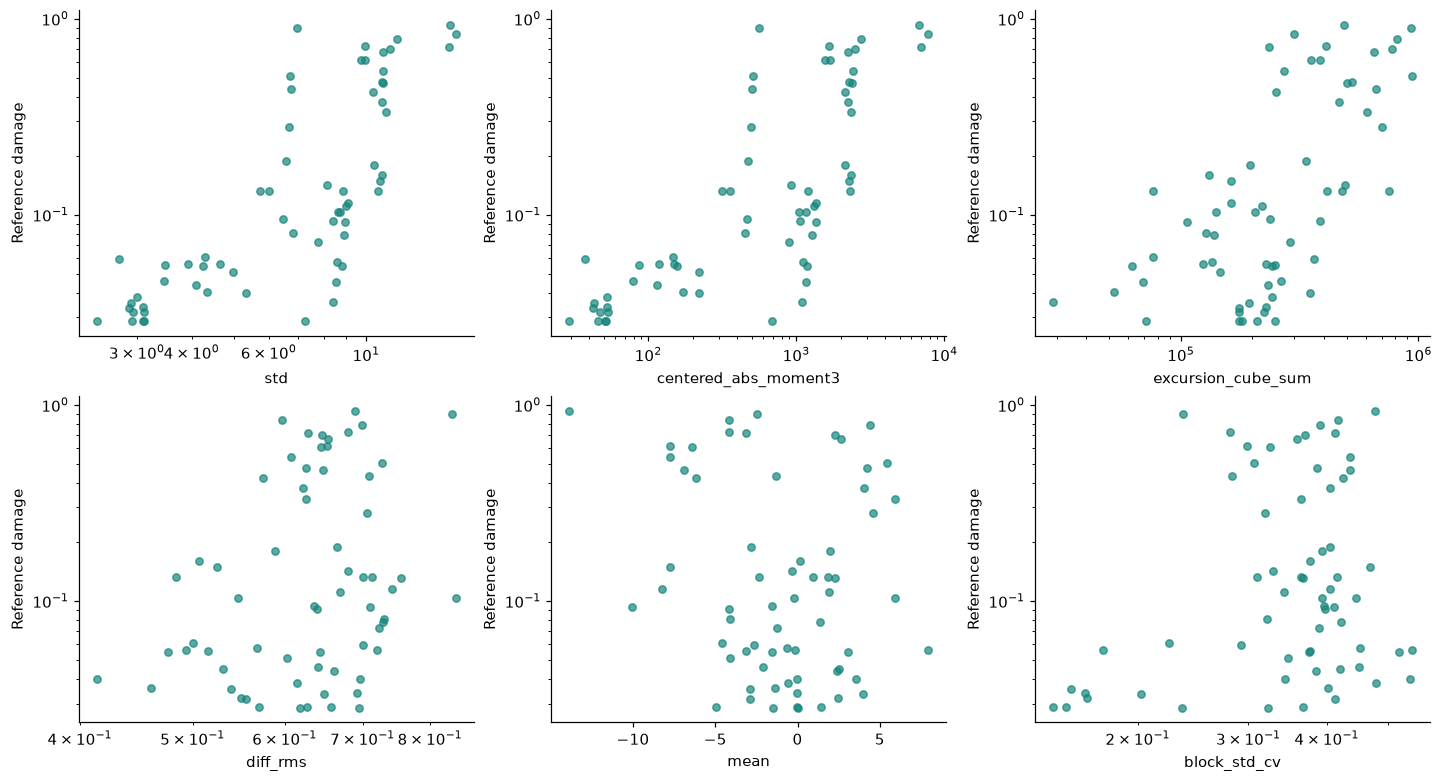

In [17]:
associations=pd.DataFrame({
    'spearman_damage':train_features[usable].corrwith(train_features.damage,method='spearman'),
    'pearson_damage':train_features[usable].corrwith(train_features.damage),
    'pearson_log_damage':train_features[usable].corrwith(np.log(train_features.damage))})
associations['abs_spearman']=associations.spearman_damage.abs()
associations=associations.sort_values('abs_spearman',ascending=False)
display(associations.round(3))
fig,axes=plt.subplots(2,3,figsize=(13,7))
for ax,col in zip(axes.flat,['std','centered_abs_moment3','excursion_cube_sum','diff_rms','mean','block_std_cv']):
    ax.scatter(train_features[col],train_features.damage,s=23,alpha=.7,color=COLORS['Train'])
    ax.set(xlabel=col,ylabel='Reference damage',yscale='log')
    if train_features[col].gt(0).all(): ax.set_xscale('log')
plt.show()

<blockquote><h3 id="8-2"><b>8.2 Redundant Feature Groups</b></h3></blockquote>

A Spearman matrix and high-correlation pairs identify summaries that may carry similar information. Redundancy is relevant because only 64 labelled files support later model fitting.

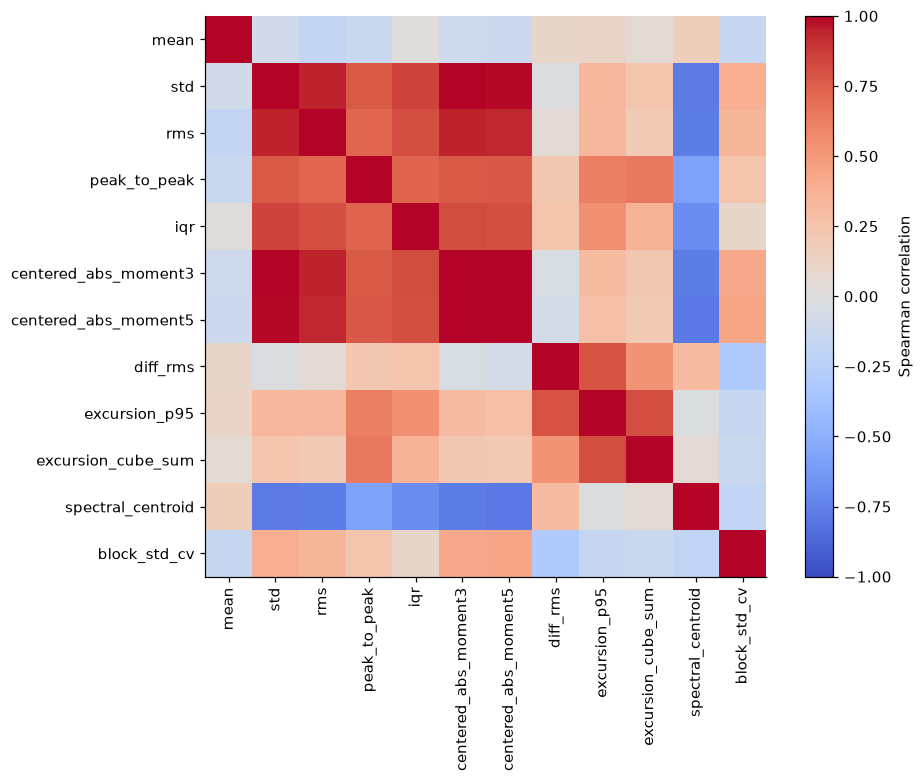

,feature_a,feature_b,spearman
0,std,centered_abs_moment3,0.995559
1,std,centered_abs_moment5,0.991392
2,centered_abs_moment3,centered_abs_moment5,0.996612


In [18]:
REDUNDANCY=['mean','std','rms','peak_to_peak','iqr','centered_abs_moment3','centered_abs_moment5',
            'diff_rms','excursion_p95','excursion_cube_sum','spectral_centroid','block_std_cv']
corr=train_features[REDUNDANCY].corr(method='spearman')
fig,ax=plt.subplots(figsize=(9,7))
im=ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm')
ax.set(xticks=range(len(corr)),yticks=range(len(corr)),xticklabels=corr.columns,yticklabels=corr.columns)
ax.tick_params(axis='x',rotation=90); fig.colorbar(im,ax=ax,label='Spearman correlation'); plt.show()
pairs=[{'feature_a':a,'feature_b':b,'spearman':corr.loc[a,b]} for i,a in enumerate(corr.columns)
       for b in corr.columns[i+1:] if abs(corr.loc[a,b])>=.95]
display(pd.DataFrame(pairs,columns=['feature_a','feature_b','spearman']))

<blockquote><h3 id="8-3"><b>8.3 Association Uncertainty and Influence</b></h3></blockquote>

Bootstrap intervals resample whole Train files for four preselected summaries. Leave-one-file-out correlation ranges identify sensitivity to individual observations. These intervals assume independent files; missing line and load metadata prevents verification of that assumption.

In [19]:
rng=np.random.default_rng(SEED)
uncertainty=[]
y=train_features.damage.to_numpy()
for col in ['std','diff_rms','excursion_cube_sum','spectral_centroid']:
    x=train_features[col].to_numpy()
    boot=[]
    for _ in range(1000):
        idx=rng.integers(0,len(y),len(y))
        boot.append(stats.spearmanr(x[idx],y[idx]).statistic)
    loo=[stats.spearmanr(np.delete(x,i),np.delete(y,i)).statistic for i in range(len(y))]
    lo,hi=np.nanquantile(boot,[.025,.975])
    uncertainty.append({'feature':col,'spearman':stats.spearmanr(x,y).statistic,
                        'bootstrap_low':lo,'bootstrap_high':hi,'leave_one_out_min':min(loo),'leave_one_out_max':max(loo)})
display(pd.DataFrame(uncertainty).round(3))

,feature,spearman,bootstrap_low,bootstrap_high,leave_one_out_min,leave_one_out_max
0,std,0.802,0.673,0.887,0.792,0.827
1,diff_rms,0.255,0.044,0.447,0.222,0.287
2,excursion_cube_sum,0.615,0.442,0.725,0.597,0.634
3,spectral_centroid,-0.654,-0.791,-0.474,-0.694,-0.637


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Train and Test Coverage Comparison</b></h2>
</div>

This section compares feature coverage without Test targets. Differences can reflect load conditions, lines, or other acquisition factors, but those causes cannot be identified from the supplied per-file metadata.

<blockquote><h3 id="9-1"><b>9.1 Train-Scaled Distribution Shift</b></h3></blockquote>

Median shifts are scaled by the Train IQR, and Test values outside the observed Train range are counted. Small sample sizes and unknown Test target mixture limit interpretation.

In [20]:
train_iqr=train_features[usable].quantile(.75)-train_features[usable].quantile(.25)
shift=pd.DataFrame({'train_median':train_features[usable].median(),'test_median':test_features[usable].median(),
    'median_shift_train_IQR':(test_features[usable].median()-train_features[usable].median())/train_iqr.replace(0,np.nan),
    'test_outside_train_range':((test_features[usable]<train_features[usable].min())|
                                (test_features[usable]>train_features[usable].max())).sum()})
display(shift.sort_values('test_outside_train_range',ascending=False).round(4))

,train_median,test_median,median_shift_train_IQR,test_outside_train_range
iqr,7.1643,7.7595,0.1455,2
mean,-0.6177,-0.5960,0.0039,1
rms,8.5527,10.6951,0.3697,1
peak_to_peak,59.0345,58.4560,-0.0220,1
minimum,-31.1750,-30.4738,0.0549,1
excess_kurtosis,0.6492,0.4987,-0.2279,1
skew,-0.0778,0.1889,0.6694,1
spectral_centroid,0.0111,0.0087,-0.2934,1
reversal_density,0.5909,0.5912,0.0077,1
spectral_fraction_low,0.8841,0.9103,0.3232,1


<blockquote><h3 id="9-2"><b>9.2 Feature-Space Coverage</b></h3></blockquote>

Two pairs of descriptive features visualise Train coverage and unlabelled Test positions. Train colour indicates known damage only; the Test markers carry no inferred damage values.

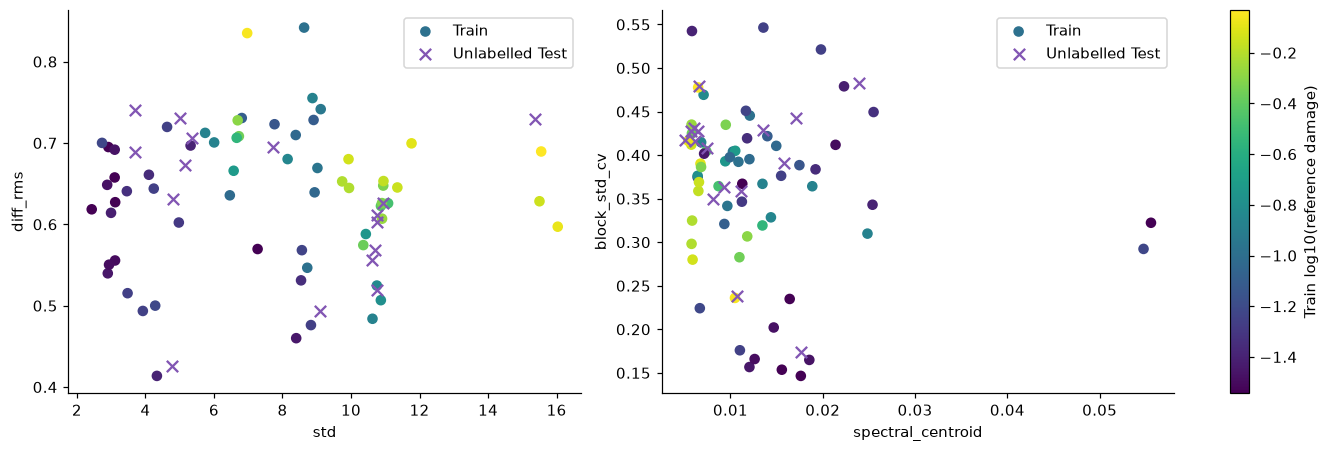

In [21]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,(a,b) in zip(axes,[('std','diff_rms'),('spectral_centroid','block_std_cv')]):
    sc=ax.scatter(train_features[a],train_features[b],c=np.log10(train_features.damage),cmap='viridis',label='Train',s=35)
    ax.scatter(test_features[a],test_features[b],marker='x',color=COLORS['Test'],label='Unlabelled Test',s=55)
    ax.set(xlabel=a,ylabel=b); ax.legend()
fig.colorbar(sc,ax=axes,label='Train log10(reference damage)'); plt.show()

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-10" style="color: black;"><b>Section 10: Validation Planning and Leakage Controls</b></h2>
</div>

This section prepares a reproducible candidate split at the labelled-recording level. It does not fit a model or report validation performance.

<blockquote><h3 id="10-1"><b>10.1 Candidate Recording-Level Folds</b></h3></blockquote>

Train files are stratified across four damage quantile bands and distributed among four folds with a fixed seed. Exact duplicate signals must remain together; this candidate is withheld if duplicates exist. File identity, label values, target bands, and fold numbers are metadata, not predictive features.

In [22]:
train_quality=quality.query("dataset == 'Train'").set_index('filename')
fold_manifest=None
if train_quality.signal_hash.duplicated().any():
    print('Exact duplicate groups require grouped splitting before a candidate manifest can be defined.')
else:
    fold_manifest=labels.copy()
    fold_manifest['target_band']=pd.qcut(fold_manifest.damage,4,labels=False)
    fold_manifest['fold']=-1
    rng=np.random.default_rng(SEED)
    for band,g in fold_manifest.groupby('target_band'):
        shuffled=rng.permutation(g.index.to_numpy())
        fold_manifest.loc[shuffled,'fold']=np.arange(len(shuffled))%4
    assert fold_manifest.fold.ge(0).all()
    display(fold_manifest.groupby('fold').damage.agg(['size','min','median','max']))
    display(pd.crosstab(fold_manifest.fold,fold_manifest.target_band))

,size,min,median,max
fold,,,,
0,16,0.028620,0.095984,0.832608
1,16,0.028737,0.098207,0.894736
2,16,0.033974,0.098931,0.716510
3,16,0.028623,0.094438,0.928339


target_band,0,1,2,3
fold,,,,
0,4,4,4,4
1,4,4,4,4
2,4,4,4,4
3,4,4,4,4


<blockquote><h3 id="10-2"><b>10.2 Modelling Constraints and Evaluation Plan</b></h3></blockquote>

The following planning table relates observations and documentation limits to later modelling decisions. It defines requirements rather than fitted-model conclusions.

In [23]:
planning=pd.DataFrame([
    ('Target and metric','Predict positive file-level damage; evaluate fractional MAPE and max(0, 1-MAPE), with MAE and errors by damage range as diagnostics.'),
    ('Candidate feature families','Compare compact amplitude, excursion, and spectral summaries; all-feature models may overfit 64 files.'),
    ('Preprocessing','Fit scaling, imputation if required, feature selection, and tuning using training folds only; preserve raw traces.'),
    ('Within-file dependence','All windows from a recording stay in the same fold. A file-level damage label is not a window-level reference target.'),
    ('Unknown groups','Seek per-file line, AW0/AW4 load, source session, and measurement-point metadata for grouped validation.'),
    ('Chronology','Random file identifiers cannot support temporal validation or degradation trajectories.'),
    ('Physical interpretation','Rainflow/Miner calculations require verified conventions, stress units, material constants, and duration. The excursion proxy is not reference damage.'),
    ('Generalisation','Healthy-only recordings cannot establish structural fault detection or remaining-life forecasting.'),
    ('Test use','Use Test only for descriptive coverage here; model and threshold selection must use Train validation.')
],columns=['topic','modelling implication'])
display(planning)

,topic,modelling implication
0,Target and metric,Predict positive file-level damage; evaluate f...
1,Candidate feature families,"Compare compact amplitude, excursion, and spec..."
2,Preprocessing,"Fit scaling, imputation if required, feature s..."
3,Within-file dependence,All windows from a recording stay in the same ...
4,Unknown groups,"Seek per-file line, AW0/AW4 load, source sessi..."
5,Chronology,Random file identifiers cannot support tempora...
6,Physical interpretation,Rainflow/Miner calculations require verified c...
7,Generalisation,Healthy-only recordings cannot establish struc...
8,Test use,Use Test only for descriptive coverage here; m...


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-11" style="color: black;"><b>Section 11: Reproducibility and Results Inventory</b></h2>
</div>

This section records the scale of the completed audit and provides compact numerical results for the conclusion section. The notebook retains all tables and figures without exporting model-ready training data or predictions.

<blockquote><h3 id="11-1"><b>11.1 Analysis Summary</b></h3></blockquote>

The summary records file counts, target scale, quality issues, duplicate checks, and outlier counts. These values support the dedicated conclusions rather than implying predictive performance.

In [24]:
summary={
    'train_files':len(train_features),'test_files':len(test_features),
    'min_samples':int(quality.rows.min()),'max_samples':int(quality.rows.max()),
    'invalid_cells':int(quality[['missing_cells','nonnumeric_cells','infinite_cells']].sum().sum()),
    'constant_files':int(quality.constant_signal.sum()),
    'files_in_exact_duplicate_groups':len(duplicate_files),
    'target_min':float(labels.damage.min()),'target_median':float(labels.damage.median()),'target_max':float(labels.damage.max()),
    'candidate_features':len(FEATURES),
    'train_outlier_files':int(outlier_review.loc['Train'].flag_count.gt(0).sum()),
    'test_outlier_files':int(outlier_review.loc['Test'].flag_count.gt(0).sum()),
    'test_features_with_out_of_range_values':int(shift.test_outside_train_range.gt(0).sum()),
    'top_association_feature':associations.index[0],
    'top_association_spearman':float(associations.iloc[0].spearman_damage)}
display(pd.Series(summary,name='observed result'))

train_files                                         64
test_files                                          16
min_samples                                     581120
max_samples                                     581120
invalid_cells                                        0
constant_files                                       0
files_in_exact_duplicate_groups                      0
target_min                                     0.02862
target_median                                 0.098931
target_max                                    0.928339
candidate_features                                  33
train_outlier_files                                  4
test_outlier_files                                   0
test_features_with_out_of_range_values              10
top_association_feature                   peak_to_peak
top_association_spearman                      0.962454
Name: observed result, dtype: object

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-12" style="color: black;"><b>Section 12: Findings, Limitations, and Modelling Handoff</b></h2>
</div>

This section consolidates observed results and the limitations that matter for subsequent model development.

<blockquote><h3 id="12-1"><b>12.1 Verified Data and Target Findings</b></h3></blockquote>

- All 64 Train recordings and 16 Test recordings contain one numeric channel with 581,120 samples. No missing, non-numeric, or infinite readings, constant recordings, or exact duplicate recordings were found.
- Every Train file has exactly one valid, positive damage target. Targets range from approximately 0.028620 to 0.928339, with a median of 0.098931. This approximately 32-fold range makes relative-error analysis relevant to the official MAPE-derived score.
- The analysis constructs 33 candidate features. Peak-to-peak stress has the strongest absolute Train Spearman association with damage among these features, approximately 0.962. This is an in-sample association, not a validation result or an established physical damage formula.
- Standard deviation has a Train Spearman association of approximately 0.802 with damage; its file-bootstrap 95% interval is approximately 0.673–0.887. The adjacent-excursion cubic proxy has a weaker association of approximately 0.615, reinforcing that the proxy cannot replace verified rainflow counting and material calibration.
- The selected robust feature screen flags 4 Train recordings and no Test recordings. Separately, 10 candidate features contain at least one Test value outside the observed Train range. These screens measure different properties; neither establishes fault status or model failure.
- Four candidate validation folds contain 16 Train files each, with damage-range balance. They remain provisional because line, load, and session identifiers are unavailable.

<blockquote><h3 id="12-2"><b>12.2 Feature and Validation Implications</b></h3></blockquote>

The amplitude, excursion, and spectral summaries provide candidate inputs for later regression comparisons. Correlations and robust outlier flags describe the available recordings; they do not establish held-out predictive accuracy. Large-damage and flagged recordings remain part of the raw dataset.

Whole recordings are the unit of validation. The candidate folds balance target ranges but cannot control unknown line, load, or session dependence. Any later preprocessing, feature selection, or parameter tuning requires fitting inside the training folds.

<blockquote><h3 id="12-3"><b>12.3 Unresolved Information and Scope</b></h3></blockquote>

Physical frequency interpretation requires the sampling rate. Calibrated fatigue calculations require stress units, material S–N constants, and counting conventions. Duration, source grouping, and acquisition context require confirmation before operational interpretation.

The supplied healthy-condition data and file-level cumulative-damage labels do not validate structural-fault detection, future-failure prediction, or remaining useful life. Modelling, experiment tracking, dashboards, and deployment remain subsequent stages.